In [1]:
import matplotlib.pyplot as plt
from numba import njit
import numpy as np
import os
from scipy.interpolate import CubicSpline
import sys
from tqdm import tqdm


In [2]:
@njit
def calculate_laplacian(dz, field):
    laplacian = np.zeros_like(field)
    N = len(field)
    
    for i in range(N):
        laplacian[i] = field[(i+1)%N] + field[(i-1)%N] - 2*field[i%N]

    return laplacian/dz**2
    
def calculate_mu(dz, m):
    return -m + m**3 - calculate_laplacian(dz, m)

# def calculate_mu_perp(dz, s, string):
#     n, N = string.shape
#     mu_perp = np.zeros_like(string)
#     t = np.zeros_like(string)

#     for iz in range(N):
#         spline = CubicSpline(s, string[:, iz], bc_type='natural')
#         t[:, iz] = spline.derivative()(s)


#     for is_ in range(1, n-1):
#         mu = calculate_mu(dz, string[is_])
        
#         t_ = t[is_]
#         # mu_perp[is_] = mu - (np.dot(t_, mu)/np.dot(t_, t_)) * t_

#         dot_tt = np.dot(t_, t_)
#         if dot_tt < 1e-6:
#             dot_tt = 1e-6  # Regularize
#         mu_perp[is_] = mu - (np.dot(t_, mu) / dot_tt) * t_

#     return mu_perp

Text(0, 0.5, 'm_in')

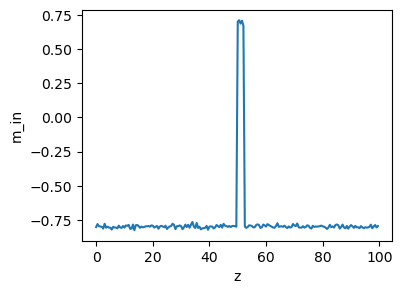

In [3]:
# Space params
L = 100
N = 200
dz = L/N

z = np.linspace(0, L, N, endpoint=False)

# Initial Homogeneous state
m0 =-0.8
m = np.ones(N)*m0

# Small Perturbation to the initial homogeneous state
m[N//2:N//2+5] = 0.7
m += np.random.normal(0, 0.01, size=N)
m_in = m.copy()

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(z, m)
ax.set_xlabel("z")
ax.set_ylabel("m_in")


In [4]:
epsilon = 1e-3
steps = 1_000_000

In [5]:
snapshots = []
for step in tqdm(range(steps)):
    # mu =  -m + m**3 - calculate_laplacian(dz, m)
    
    m += calculate_laplacian(dz, calculate_mu(dz, m)) * epsilon
    
    if step%10_000 == 0:
        snapshots.append(m.copy())


100%|██████████████████████████████| 1000000/1000000 [00:23<00:00, 42084.18it/s]


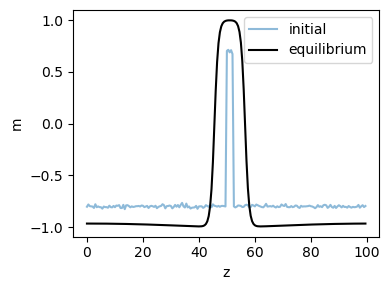

In [6]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(z, m_in, label="initial", alpha=0.5)
ax.plot(z, m, color="k", label="equilibrium")

# for idx, snapshot in enumerate(snapshots[::50]):    
#     ax.plot(z, snapshot, alpha=(idx+1)/(len(snapshots)+1), color="k")

ax.set_xlabel("z")
ax.set_ylabel("m")
ax.legend(loc="upper right")
fig.tight_layout()

In [105]:
# contour discretization
n = 20
flag = 0

s_uniform = np.linspace(0, 1, n, endpoint=True)
tol = 1e-6
e = 0.01

max_iter = 10501

string = np.empty((n, N))

# String ends fixed
string[0, :] = m_in.copy()
string[-1, :] = m.copy()

# Intermediate string points
for is_ in range(1, n-1):
    if is_ < n//2:
        string[is_] = np.ones(N) * m0
    else:
        string[is_] = m



In [107]:
for iter_ in range(max_iter):
    for is_ in range(1, n-1):
        string[is_, :] -= calculate_mu(dz, string[is_]) * e
    
    s_primes = np.zeros(n)

    deltas = []

    for is_ in range(0, n-1):
        delta = np.sqrt(np.sum((string[is_+1, :]-string[is_])**2))
        if delta < 1e-6:
            delta = 1e-6
        deltas.append(delta)

    s_primes = []
    for is_ in range(0, n):
        s_prime = np.sum(deltas[:is_])/np.sum(deltas)
        s_primes.append(s_prime)

    s_primes = np.asarray(s_primes)
    # print(np.asarray(s_primes))

    new_string = np.zeros_like(string)
    t = np.zeros_like(string)
    for iz in range(N):
        cs = CubicSpline(s_primes, string[:, iz], bc_type="natural")
        new_string[:, iz] = cs(s_uniform)
        
        t[:, iz] = cs.derivative()(s_uniform)

    mu_perp = np.zeros_like(string)

    mu = calculate_mu(dz, new_string)
    for is_ in range(n):
        mu_perp[is_, :] = mu[is_, :] - (np.dot(t[is_, :], mu[is_, :])/np.dot(t[is_, :], t[is_, :]))*t[is_, :]
    # print(mu_perp)

    string = new_string
    string[0, :] = m_in.copy()
    string[-1, :] = m.copy()        

    if iter_%100==0:
        # print(mu_perp)
        norms = [np.linalg.norm(mu_perp[is_]) for is_ in range(1, n-1)]
        print(f"Iteration {iter_}: max residual = {np.max(norms):.2e}, min residual = {np.min(norms):.2e}, mean = {np.mean(norms):.2e}")        
    

Iteration 0: max residual = 6.06e+00, min residual = 2.06e-01, mean = 1.47e+00
Iteration 100: max residual = 6.40e+00, min residual = 2.09e-01, mean = 2.16e+00
Iteration 200: max residual = 7.21e+00, min residual = 8.16e-02, mean = 1.90e+00
Iteration 300: max residual = 6.20e+00, min residual = 2.88e-01, mean = 2.24e+00
Iteration 400: max residual = 6.02e+00, min residual = 1.41e-01, mean = 2.12e+00
Iteration 500: max residual = 6.21e+00, min residual = 2.72e-01, mean = 2.41e+00
Iteration 600: max residual = 5.55e+00, min residual = 1.85e-01, mean = 2.29e+00
Iteration 700: max residual = 6.08e+00, min residual = 1.19e-01, mean = 1.48e+00
Iteration 800: max residual = 5.78e+00, min residual = 3.01e-01, mean = 1.99e+00
Iteration 900: max residual = 5.92e+00, min residual = 1.38e-01, mean = 2.11e+00
Iteration 1000: max residual = 7.03e+00, min residual = 1.21e-01, mean = 1.56e+00
Iteration 1100: max residual = 6.61e+00, min residual = 2.70e-01, mean = 2.46e+00
Iteration 1200: max residual

KeyboardInterrupt: 

In [108]:
n, N = string.shape
    
# Compute tangent vectors t_s[is, iz]
t = np.zeros_like(string)
for iz in range(N):
    spline = CubicSpline(s_uniform, string[:, iz], bc_type='natural')
    t[:, iz] = spline.derivative()(s_uniform)

# Compute chemical potentials mu_s[is, iz]
mu = np.zeros_like(string)
for is_ in range(n):
    mu[is_] = calculate_mu(dz, string[is_])
    mu[is_] -= np.mean(mu[is_])  # mass conservation

# Compute free energy difference
dF = 0.0
for is_ in range(n - 1):
    ds = s_uniform[is_ + 1] - s_uniform[is_]
    integrand = np.sum(mu[is_] * t[is_])
    dF += ds * integrand

In [109]:
dF

-11.754985703282674

In [110]:
def free_energy_functional(dz, m):
    return np.sum(0.25 * (m**2 - 1)**2 + 0.5 * (np.gradient(m, dz))**2) * dz
F0 = free_energy_functional(dz, string[0])
F1 = free_energy_functional(dz, string[-1])
print(f"Direct ΔF = {F1 - F0:.6f}")


Direct ΔF = -3.688245
